In [ ]:
# STEP 0: Install libraries
!pip install pmdarima -q

import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from pmdarima import auto_arima

# STEP 1: Upload Excel file
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_excel(file_name)

print(df.head())
print(df.columns)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 14.4 MB/s eta 0:00:00


Saving DATA6000 WEEK 5 power bi.xlsx to DATA6000 WEEK 5 power bi.xlsx
        Date  Production     Demand  P-C (BCF)  X (BCF)  I (BCF)  E-I (BCF)  \
0 1993-01-01   70.358453  58.403239  11.955214      NaN      NaN        NaN   
1 1993-02-01   65.685188  52.774570  12.910618      NaN      NaN        NaN   
2 1993-03-01   72.790423  62.195367  10.595057      NaN      NaN        NaN   
3 1993-04-01   75.389141  63.853710  11.535432      NaN      NaN        NaN   
4 1993-05-01   80.839339  70.422844  10.416494      NaN      NaN        NaN   

   GDP per capita USD  Population  GDP USD  C RESIDENTIAL  C COMERCIAL  \
0                 NaN         NaN      NaN       6.428194     1.334931   
1                 NaN         NaN      NaN       5.811705     1.171989   
2                 NaN         NaN      NaN       7.658346     1.828277   
3                 NaN         NaN      NaN       9.904890     1.952232   
4                 NaN         NaN      NaN      20.654720     3.132873   

   C OFFIC


--- ADF Test for Demand ---
ADF Statistic: -2.190581664552419
p-value: 0.20968151061393325
Result: Non-stationary. Differencing is needed.


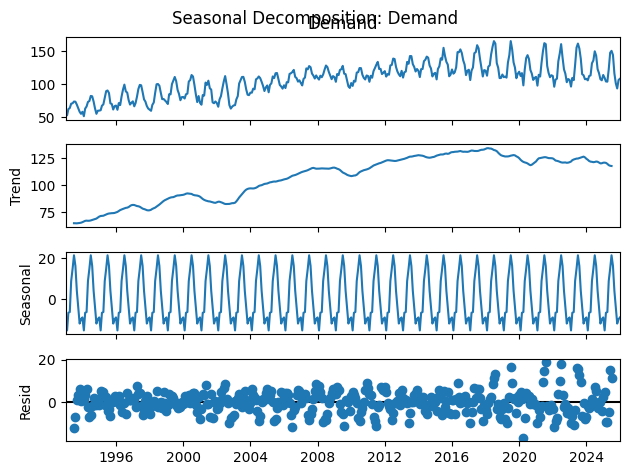

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=2390.915, Time=7.05 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=2913.396, Time=0.11 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=2523.531, Time=0.97 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=2734.414, Time=1.88 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=2911.465, Time=0.12 sec
 ARIMA(2,1,2)(0,0,1)[12] intercept   : AIC=2710.076, Time=8.76 sec
 ARIMA(2,1,2)(1,0,0)[12] intercept   : AIC=2483.759, Time=6.01 sec
 ARIMA(2,1,2)(2,0,1)[12] intercept   : AIC=2392.766, Time=10.40 sec
 ARIMA(2,1,2)(1,0,2)[12] intercept   : AIC=2392.830, Time=7.88 sec
 ARIMA(2,1,2)(0,0,0)[12] intercept   : AIC=2825.228, Time=0.76 sec
 ARIMA(2,1,2)(0,0,2)[12] intercept   : AIC=inf, Time=5.71 sec
 ARIMA(2,1,2)(2,0,0)[12] intercept   : AIC=2424.238, Time=7.65 sec
 ARIMA(2,1,2)(2,0,2)[12] intercept   : AIC=2394.836, Time=6.47 sec
 ARIMA(1,1,2)(1,0,1)[12] intercept   : AIC=2388.103, Time=1.86 sec
 ARIMA(1,1,2)(0,0,1)[12

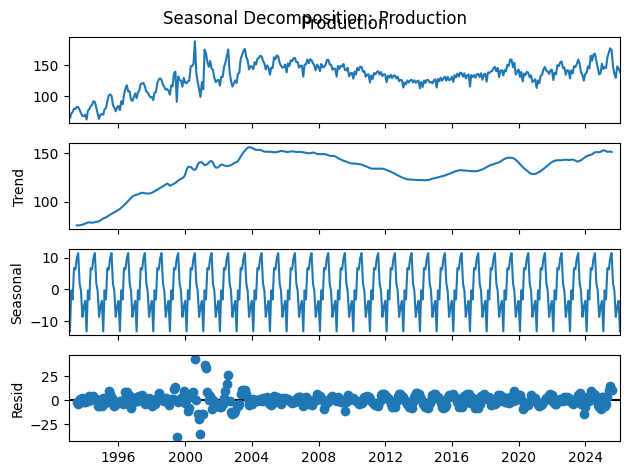

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=2678.531, Time=2.44 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=2943.079, Time=0.04 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=2799.743, Time=0.39 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=2851.121, Time=0.54 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=2941.200, Time=0.03 sec
 ARIMA(2,1,2)(0,0,1)[12] intercept   : AIC=2813.069, Time=0.89 sec
 ARIMA(2,1,2)(1,0,0)[12] intercept   : AIC=2756.561, Time=2.14 sec
 ARIMA(2,1,2)(2,0,1)[12] intercept   : AIC=2680.522, Time=8.20 sec
 ARIMA(2,1,2)(1,0,2)[12] intercept   : AIC=2680.496, Time=5.98 sec
 ARIMA(2,1,2)(0,0,0)[12] intercept   : AIC=2886.088, Time=0.42 sec
 ARIMA(2,1,2)(0,0,2)[12] intercept   : AIC=2774.667, Time=4.86 sec
 ARIMA(2,1,2)(2,0,0)[12] intercept   : AIC=2712.207, Time=3.58 sec
 ARIMA(2,1,2)(2,0,2)[12] intercept   : AIC=2682.444, Time=6.36 sec
 ARIMA(1,1,2)(1,0,1)[12] intercept   : AIC=2677.139, Time=3.95 sec
 ARIMA(1,1,2)(0,0,1

In [ ]:
# STEP 2: Test, decompose, model and forecast Demand and Production

date_col = "Date"
demand_col = "Demand"
production_col = "Production"   # change this if your column has another name

forecast_periods = 60  # monthly forecast to around 2030 if your data ends in 2026


def run_sarima_forecast(original_df, date_col, value_col, forecast_periods=60):
    temp = original_df[[date_col, value_col]].dropna().copy()
    temp[date_col] = pd.to_datetime(temp[date_col])
    temp = temp.sort_values(date_col)

    temp = temp.set_index(date_col)
    temp = temp.asfreq("MS")
    temp[value_col] = temp[value_col].interpolate()

    print(f"\n--- ADF Test for {value_col} ---")
    adf_result = adfuller(temp[value_col])
    print("ADF Statistic:", adf_result[0])
    print("p-value:", adf_result[1])

    if adf_result[1] > 0.05:
        print("Result: Non-stationary. Differencing is needed.")
    else:
        print("Result: Stationary.")

    decomposition = seasonal_decompose(temp[value_col], model="additive", period=12)
    decomposition.plot()
    plt.suptitle(f"Seasonal Decomposition: {value_col}")
    plt.show()

    model = auto_arima(
        temp[value_col],
        seasonal=True,
        m=12,
        trace=True,
        stepwise=True,
        suppress_warnings=True
    )

    print(model.summary())

    forecast, conf_int = model.predict(
        n_periods=forecast_periods,
        return_conf_int=True
    )

    future_dates = pd.date_range(
        start=temp.index[-1] + pd.DateOffset(months=1),
        periods=forecast_periods,
        freq="MS"
    )

    forecast_df = pd.DataFrame({
        "Date": future_dates,
        f"{value_col}_Forecast": forecast,
        f"{value_col}_Lower_Bound": conf_int[:, 0],
        f"{value_col}_Upper_Bound": conf_int[:, 1]
    })

    return temp, forecast_df, model


demand_actual, demand_forecast, demand_model = run_sarima_forecast(
    df, date_col, demand_col, forecast_periods
)

production_actual, production_forecast, production_model = run_sarima_forecast(
    df, date_col, production_col, forecast_periods
)

In [ ]:
# STEP 3: Merge Demand and Production forecasts

forecast_df = demand_forecast.merge(
    production_forecast,
    on="Date",
    how="inner"
)

forecast_df["Forecast_Gap_Production_minus_Demand"] = (
    forecast_df[f"{production_col}_Forecast"] - forecast_df[f"{demand_col}_Forecast"]
)

forecast_df.head()

,Date,Demand_Forecast,Demand_Lower_Bound,Demand_Upper_Bound,Production_Forecast,Production_Lower_Bound,Production_Upper_Bound,Forecast_Gap_Production_minus_Demand
0,2026-03-01,106.002326,94.637587,117.367065,147.873947,134.524808,161.223086,41.871621
1,2026-04-01,104.847073,92.473461,117.220685,145.081549,129.165829,160.997269,40.234476
2,2026-05-01,124.369459,111.436648,137.302271,157.363945,140.305238,174.422652,32.994486
3,2026-06-01,140.364252,127.083917,153.644587,156.947514,139.233135,174.661894,16.583262
4,2026-07-01,148.501896,134.982768,162.021025,163.181196,145.012296,181.350095,14.679299


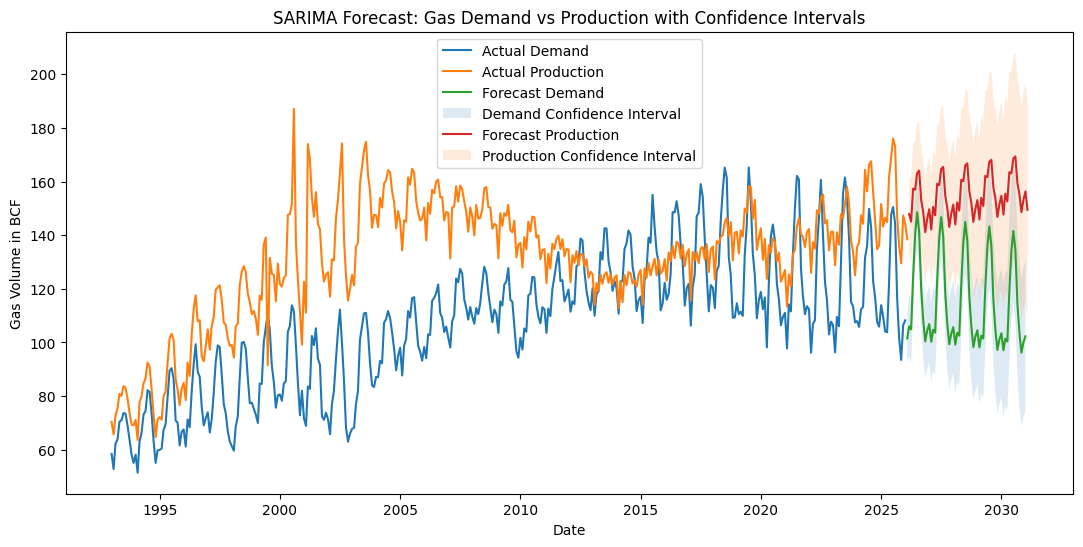

In [ ]:
# STEP 4: Plot Actual + Forecast for Demand and Production WITH Confidence Intervals

plt.figure(figsize=(13,6))

# Actual demand and production
plt.plot(demand_actual.index, demand_actual[demand_col], label="Actual Demand")
plt.plot(production_actual.index, production_actual[production_col], label="Actual Production")

# Forecast demand
plt.plot(
    demand_forecast["Date"],
    demand_forecast[f"{demand_col}_Forecast"],
    label="Forecast Demand"
)

# Demand confidence interval
plt.fill_between(
    demand_forecast["Date"],
    demand_forecast[f"{demand_col}_Lower_Bound"],
    demand_forecast[f"{demand_col}_Upper_Bound"],
    alpha=0.15,
    label="Demand Confidence Interval"
)

# Forecast production
plt.plot(
    production_forecast["Date"],
    production_forecast[f"{production_col}_Forecast"],
    label="Forecast Production"
)

# Production confidence interval
plt.fill_between(
    production_forecast["Date"],
    production_forecast[f"{production_col}_Lower_Bound"],
    production_forecast[f"{production_col}_Upper_Bound"],
    alpha=0.15,
    label="Production Confidence Interval"
)

plt.title("SARIMA Forecast: Gas Demand vs Production with Confidence Intervals")
plt.xlabel("Date")
plt.ylabel("Gas Volume in BCF")
plt.legend()
plt.show()


--- Model Evaluation: Demand ---
MAE: 3.84
RMSE: 5.62
MAPE: 3.91%
Residual Std Dev: 5.62

--- Model Evaluation: Production ---
MAE: 4.57
RMSE: 7.72
MAPE: 3.70%
Residual Std Dev: 7.71


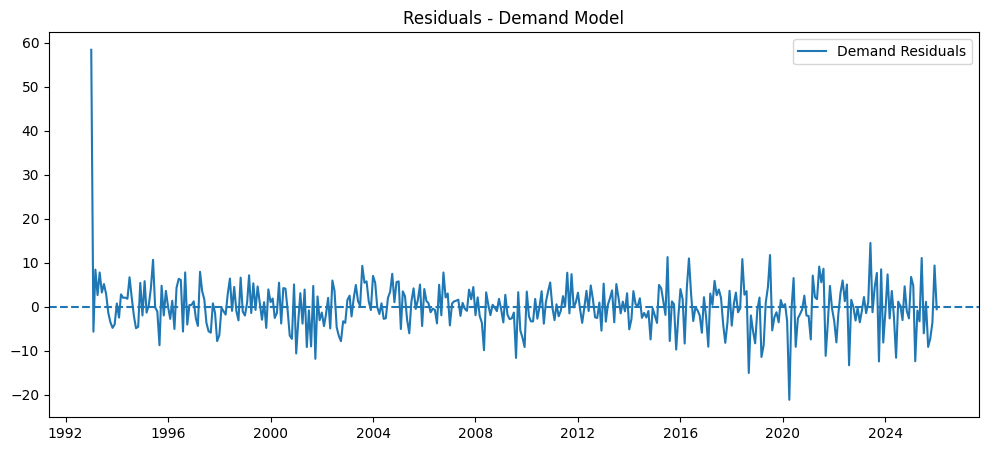

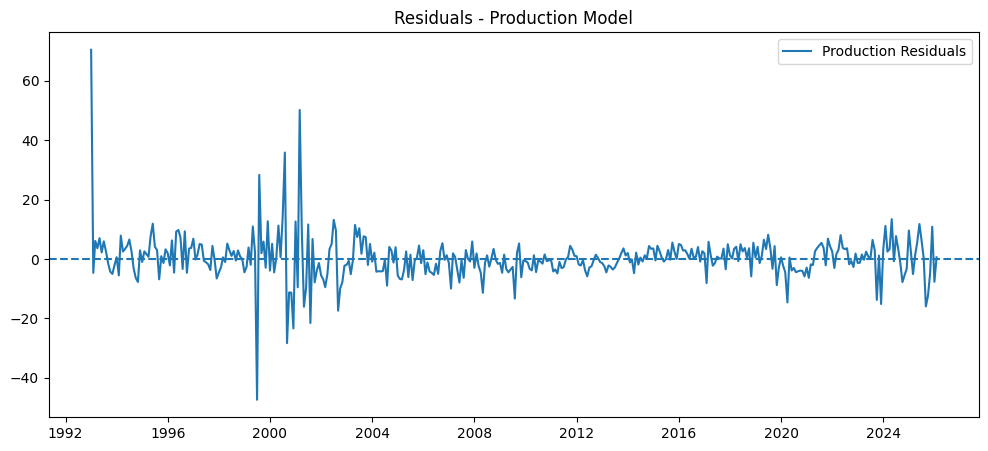

In [ ]:
# ===============================
# MODEL EVALUATION (TRAIN FIT)
# ===============================

import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate_model(actual_df, model, value_col):
    # Get fitted values (in-sample predictions)
    fitted_values = model.predict_in_sample()

    # Align with actual data
    actual_values = actual_df[value_col].values[-len(fitted_values):]

    # Metrics
    mae = mean_absolute_error(actual_values, fitted_values)
    rmse = np.sqrt(mean_squared_error(actual_values, fitted_values))
    mape = np.mean(np.abs((actual_values - fitted_values) / np.where(actual_values == 0, 1, actual_values))) * 100

    # Residuals
    residuals = actual_values - fitted_values
    std_resid = np.std(residuals)

    print(f"\n--- Model Evaluation: {value_col} ---")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAPE: {mape:.2f}%")
    print(f"Residual Std Dev: {std_resid:.2f}")


    return residuals

# Evaluate demand model
demand_residuals = evaluate_model(demand_actual, demand_model, demand_col)

# Evaluate production model
production_residuals = evaluate_model(production_actual, production_model, production_col)
plt.figure(figsize=(12,5))
plt.plot(demand_residuals, label="Demand Residuals")
plt.axhline(0, linestyle="--")
plt.title("Residuals - Demand Model")
plt.legend()
plt.show()

plt.figure(figsize=(12,5))
plt.plot(production_residuals, label="Production Residuals")
plt.axhline(0, linestyle="--")
plt.title("Residuals - Production Model")
plt.legend()
plt.show()

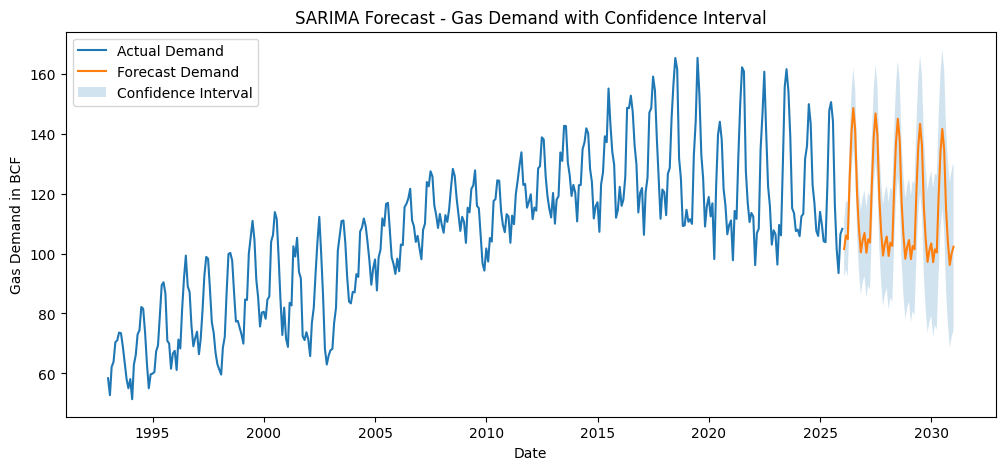

In [ ]:
# EXTRA: Demand Forecast Only with Confidence Interval

plt.figure(figsize=(12,5))

plt.plot(demand_actual.index, demand_actual[demand_col], label="Actual Demand")
plt.plot(
    demand_forecast["Date"],
    demand_forecast[f"{demand_col}_Forecast"],
    label="Forecast Demand"
)

plt.fill_between(
    demand_forecast["Date"],
    demand_forecast[f"{demand_col}_Lower_Bound"],
    demand_forecast[f"{demand_col}_Upper_Bound"],
    alpha=0.2,
    label="Confidence Interval"
)

plt.title("SARIMA Forecast - Gas Demand with Confidence Interval")
plt.xlabel("Date")
plt.ylabel("Gas Demand in BCF")
plt.legend()
plt.show()

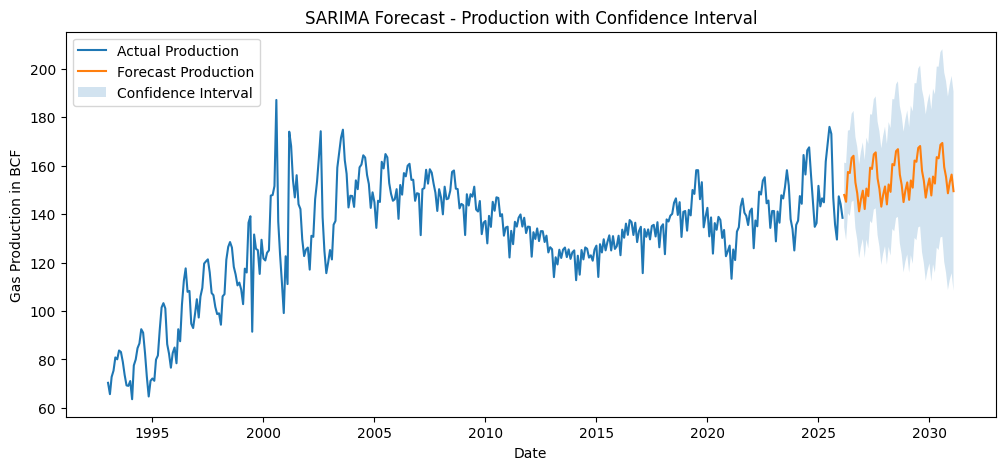

In [ ]:
# EXTRA: Production Forecast Only with Confidence Interval

plt.figure(figsize=(12,5))

plt.plot(production_actual.index, production_actual[production_col], label="Actual Production")
plt.plot(
    production_forecast["Date"],
    production_forecast[f"{production_col}_Forecast"],
    label="Forecast Production"
)

plt.fill_between(
    production_forecast["Date"],
    production_forecast[f"{production_col}_Lower_Bound"],
    production_forecast[f"{production_col}_Upper_Bound"],
    alpha=0.2,
    label="Confidence Interval"
)

plt.title("SARIMA Forecast - Production with Confidence Interval")
plt.xlabel("Date")
plt.ylabel("Gas Production in BCF")
plt.legend()
plt.show()

In [ ]:
# STEP 5: Export final table for Power BI

forecast_df.to_excel("sarima_demand_production_forecast.xlsx", index=False)

files.download("sarima_demand_production_forecast.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

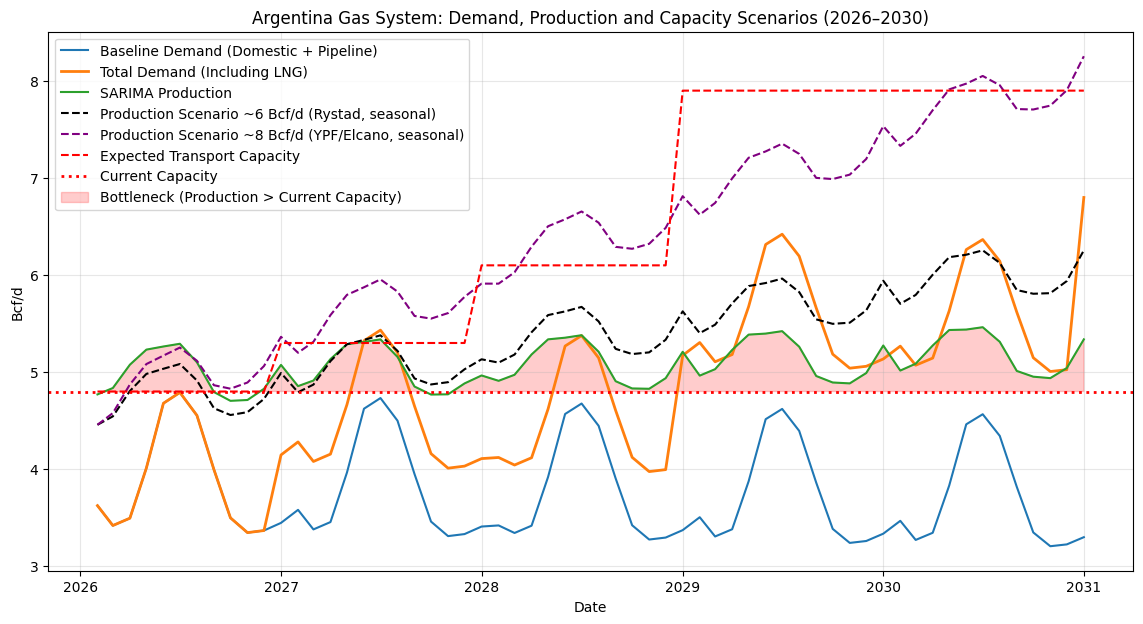

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ===============================
# FINAL SCENARIO MODEL (CLEAN)
# ===============================

# --- Convert monthly to daily ---
demand_forecast["Days_in_Month"] = demand_forecast["Date"].dt.days_in_month
production_forecast["Days_in_Month"] = production_forecast["Date"].dt.days_in_month

demand_forecast["Demand_Bcfd"] = (
    demand_forecast[f"{demand_col}_Forecast"] / demand_forecast["Days_in_Month"]
)

production_forecast["Production_Bcfd"] = (
    production_forecast[f"{production_col}_Forecast"] / production_forecast["Days_in_Month"]
)

# --- LNG demand ---
lng_demand = []

for i in range(len(demand_forecast)):
    year = demand_forecast["Date"].iloc[i].year

    if year < 2027:
        val = 0
    elif year < 2029:
        val = 0.7
    elif year < 2031:
        val = 1.8
    else:
        val = 3.5

    lng_demand.append(val)

demand_forecast["LNG_Demand_Bcfd"] = lng_demand

# --- Total demand ---
demand_forecast["Total_Demand_Bcfd"] = (
    demand_forecast["Demand_Bcfd"] + demand_forecast["LNG_Demand_Bcfd"]
)

# --- Capacity scenario ---
capacity = []

for i in range(len(demand_forecast)):
    year = demand_forecast["Date"].iloc[i].year

    if year <= 2026:
        cap = 4.8
    elif year <= 2027:
        cap = 5.3
    elif year <= 2028:
        cap = 6.1
    else:
        cap = 7.9

    capacity.append(cap)

demand_forecast["Capacity_Bcfd"] = capacity

# --- Production scenarios with seasonality ---
base_production = production_forecast["Production_Bcfd"].to_numpy()
n = len(base_production)
start_value = base_production[0]

# Linear growth trend to targets
trend_6 = np.array([
    start_value + (6.0 - start_value) * (i / (n - 1))
    for i in range(n)
])

trend_8 = np.array([
    start_value + (8.0 - start_value) * (i / (n - 1))
    for i in range(n)
])

# Keep SARIMA seasonal/monthly pattern
seasonality = base_production - np.mean(base_production)

production_forecast["Prod_6_Bcfd"] = trend_6 + seasonality
production_forecast["Prod_8_Bcfd"] = trend_8 + seasonality

# --- Common dates ---
common_dates = demand_forecast["Date"]

# ===============================
# FINAL PLOT
# ===============================

plt.figure(figsize=(14,7))

# Demand
plt.plot(
    common_dates,
    demand_forecast["Demand_Bcfd"],
    label="Baseline Demand (Domestic + Pipeline)"
)

plt.plot(
    common_dates,
    demand_forecast["Total_Demand_Bcfd"],
    linewidth=2,
    label="Total Demand (Including LNG)"
)

# Production
plt.plot(
    common_dates,
    production_forecast["Production_Bcfd"],
    label="SARIMA Production"
)

plt.plot(
    common_dates,
    production_forecast["Prod_6_Bcfd"],
    linestyle="--",
    color="black",
    label="Production Scenario ~6 Bcf/d (Rystad, seasonal)"
)

plt.plot(
    common_dates,
    production_forecast["Prod_8_Bcfd"],
    linestyle="--",
    color="purple",
    label="Production Scenario ~8 Bcf/d (YPF/Elcano, seasonal)"
)

# Capacity
plt.plot(
    common_dates,
    demand_forecast["Capacity_Bcfd"],
    linestyle="--",
    color="red",
    label="Expected Transport Capacity"
)

plt.axhline(
    4.8,
    color="red",
    linestyle=":",
    linewidth=2,
    label="Current Capacity"
)

# Bottleneck shading
plt.fill_between(
    common_dates,
    production_forecast["Production_Bcfd"],
    4.8,
    where=(production_forecast["Production_Bcfd"] > 4.8),
    color="red",
    alpha=0.2,
    interpolate=True,
    label="Bottleneck (Production > Current Capacity)"
)

plt.title("Argentina Gas System: Demand, Production and Capacity Scenarios (2026–2030)")
plt.xlabel("Date")
plt.ylabel("Bcf/d")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

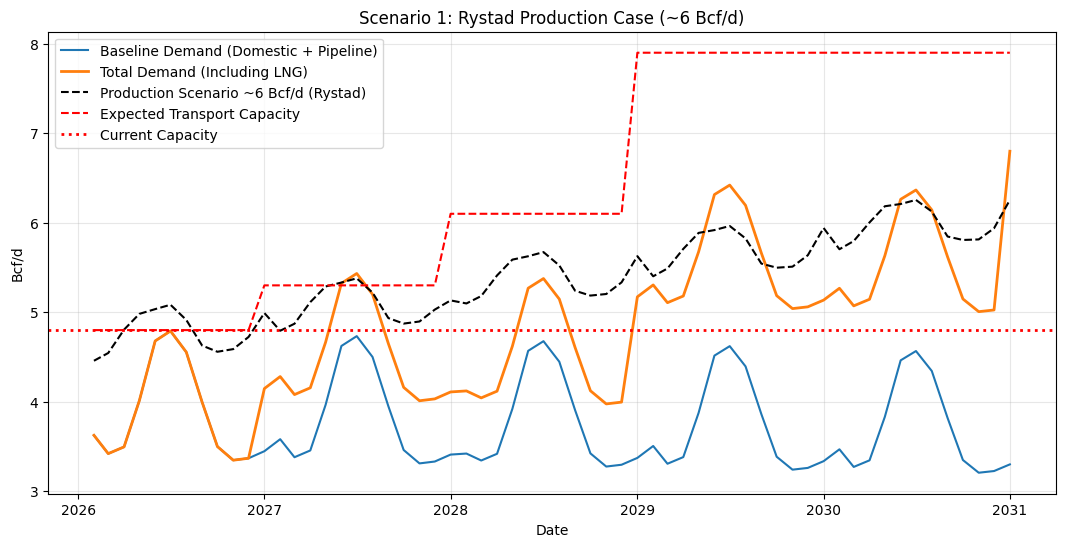

In [ ]:
# ===============================
# GRAPH 1: RYSTAD SCENARIO
# ===============================

plt.figure(figsize=(13,6))

plt.plot(common_dates, demand_forecast["Demand_Bcfd"],
         label="Baseline Demand (Domestic + Pipeline)")

plt.plot(common_dates, demand_forecast["Total_Demand_Bcfd"],
         linewidth=2,
         label="Total Demand (Including LNG)")

plt.plot(common_dates, production_forecast["Prod_6_Bcfd"],
         linestyle="--",
         color="black",
         label="Production Scenario ~6 Bcf/d (Rystad)")

plt.plot(common_dates, demand_forecast["Capacity_Bcfd"],
         linestyle="--",
         color="red",
         label="Expected Transport Capacity")

plt.axhline(4.8, color="red", linestyle=":", linewidth=2,
            label="Current Capacity")

plt.title("Scenario 1: Rystad Production Case (~6 Bcf/d)")
plt.xlabel("Date")
plt.ylabel("Bcf/d")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

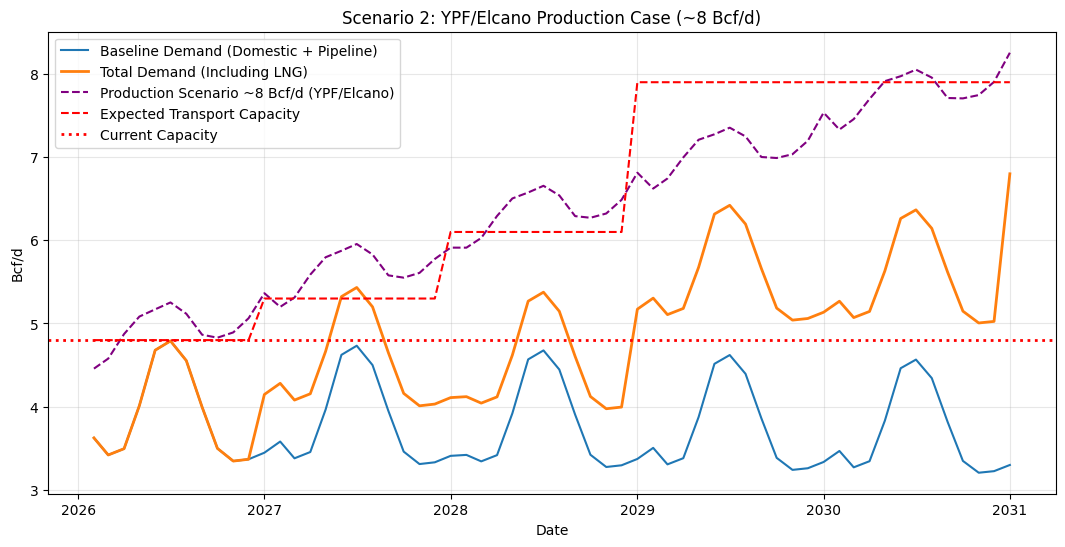

In [ ]:
# ===============================
# GRAPH 2: YPF / ELCANO SCENARIO
# ===============================

plt.figure(figsize=(13,6))

plt.plot(common_dates, demand_forecast["Demand_Bcfd"],
         label="Baseline Demand (Domestic + Pipeline)")

plt.plot(common_dates, demand_forecast["Total_Demand_Bcfd"],
         linewidth=2,
         label="Total Demand (Including LNG)")

plt.plot(common_dates, production_forecast["Prod_8_Bcfd"],
         linestyle="--",
         color="purple",
         label="Production Scenario ~8 Bcf/d (YPF/Elcano)")

plt.plot(common_dates, demand_forecast["Capacity_Bcfd"],
         linestyle="--",
         color="red",
         label="Expected Transport Capacity")

plt.axhline(4.8, color="red", linestyle=":", linewidth=2,
            label="Current Capacity")

plt.title("Scenario 2: YPF/Elcano Production Case (~8 Bcf/d)")
plt.xlabel("Date")
plt.ylabel("Bcf/d")
plt.legend()
plt.grid(alpha=0.3)
plt.show()